<a href="https://colab.research.google.com/github/LuxorLu/LuxorLu/blob/main/Coffee_regr_analis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Розвідувальний аналіз (EDA). Подивимось на графік продажів за весь рік, щоб на власні очі побачити тренд і сезонність, перш ніж будувати ознаки наосліп.

In [29]:
import pandas as pd

# завантажуємо файл у таблицю (DataFrame)
df = pd.read_csv('index_1.csv')

df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek

daily_df = df.groupby(['date', 'day_of_week'])['coffee_name'].count().reset_index()
daily_df = daily_df.sort_values('date').reset_index(drop=True)

daily_df.head()

,date,day_of_week,coffee_name
0,2024-03-01,4,11
1,2024-03-02,5,7
2,2024-03-03,6,10
3,2024-03-04,0,4
4,2024-03-05,1,9


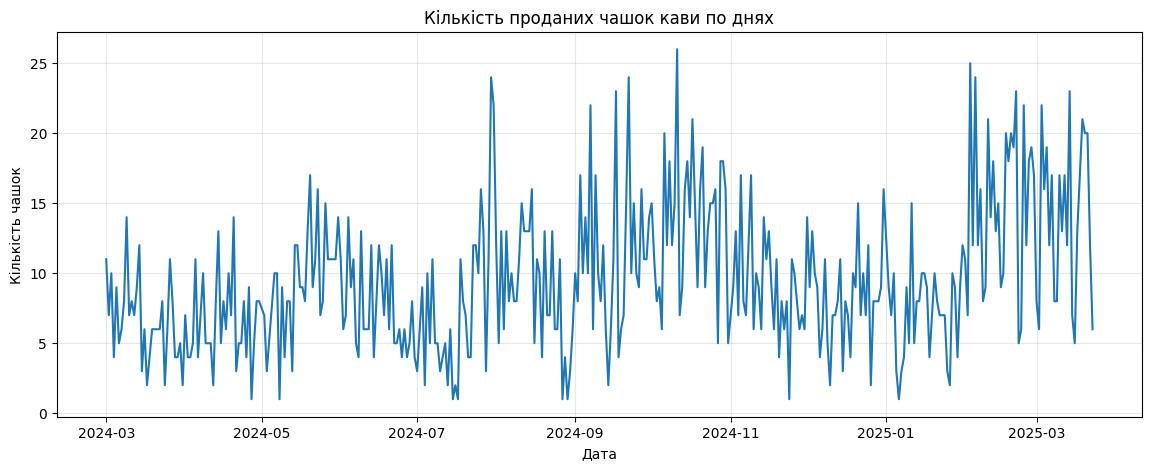

In [30]:
#графік продажів у часі:

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(daily_df['date'], daily_df['coffee_name'])
plt.title('Кількість проданих чашок кави по днях')
plt.xlabel('Дата')
plt.ylabel('Кількість чашок')
plt.grid(alpha=0.3)
plt.show()

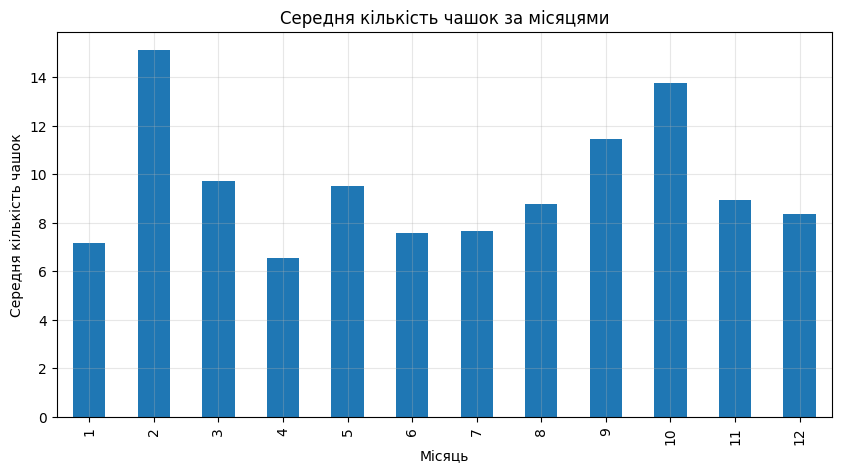

In [31]:
# розподіляємо по місяцях

daily_df['month'] = daily_df['date'].dt.month

plt.figure(figsize=(10, 5))
daily_df.groupby('month')['coffee_name'].mean().plot(kind='bar')
plt.title('Середня кількість чашок за місяцями')
plt.xlabel('Місяць')
plt.ylabel('Середня кількість чашок')
plt.grid(alpha=0.3)
plt.show()

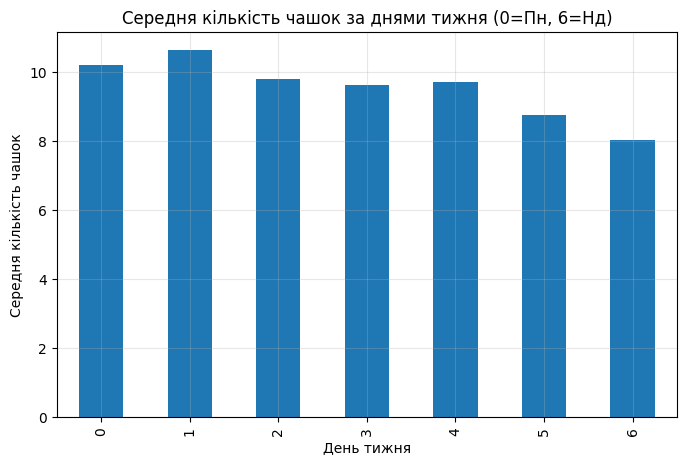

In [32]:
# розподіляємо по дням тижням

plt.figure(figsize=(8, 5))
daily_df.groupby('day_of_week')['coffee_name'].mean().plot(kind='bar')
plt.title('Середня кількість чашок за днями тижня (0=Пн, 6=Нд)')
plt.xlabel('День тижня')
plt.ylabel('Середня кількість чашок')
plt.grid(alpha=0.3)
plt.show()

Створюємо ознаки

In [33]:
# встановлюємо бібліотеку свят
!pip install holidays -q

import holidays


daily_df = daily_df.sort_values('date').reset_index(drop=True)

daily_df['is_weekend'] = daily_df['day_of_week'].isin([5, 6]).astype(int) # вихідні

ua_holidays = holidays.Ukraine(years=[2024, 2025])    # державні свята України
daily_df['is_holiday'] = daily_df['date'].isin(ua_holidays).astype(int)


daily_df['month'] = daily_df['date'].dt.month  # сезонність через sin/cos
daily_df['month_sin'] = np.sin(2 * np.pi * daily_df['month'] / 12)
daily_df['month_cos'] = np.cos(2 * np.pi * daily_df['month'] / 12)

daily_df['day_number'] = (daily_df['date'] - daily_df['date'].min()).dt.days  # тренд


daily_df['sales_yesterday'] = daily_df['coffee_name'].shift(1) # лаги
daily_df['sales_last_week'] = daily_df['coffee_name'].shift(7)

# прибираємо рядки з NaN (перші 7 днів, де лаги неповні)
daily_df_clean = daily_df.dropna().reset_index(drop=True)

daily_df_clean.head()

,date,day_of_week,coffee_name,month,is_weekend,is_holiday,month_sin,month_cos,day_number,sales_yesterday,sales_last_week
0,2024-03-08,4,8,3,0,0,1.0,6.123234e-17,7,6.0,11.0
1,2024-03-09,5,14,3,1,0,1.0,6.123234e-17,8,8.0,7.0
2,2024-03-10,6,7,3,1,0,1.0,6.123234e-17,9,14.0,10.0
3,2024-03-11,0,8,3,0,0,1.0,6.123234e-17,10,7.0,4.0
4,2024-03-12,1,7,3,0,0,1.0,6.123234e-17,11,8.0,9.0


In [41]:
print(daily_df_clean[daily_df_clean['is_holiday'] == 1][['date', 'is_holiday']])

Empty DataFrame
Columns: [date, is_holiday]
Index: []


In [36]:
daily_df = daily_df.sort_values('date').reset_index(drop=True)

daily_df['is_weekend'] = daily_df['day_of_week'].isin([5, 6]).astype(int)

ua_holidays = holidays.Ukraine(years=[2024, 2025])
daily_df['is_holiday'] = daily_df['date'].dt.date.isin(ua_holidays).astype(int)  # виправлено

daily_df['month'] = daily_df['date'].dt.month
daily_df['month_sin'] = np.sin(2 * np.pi * daily_df['month'] / 12)
daily_df['month_cos'] = np.cos(2 * np.pi * daily_df['month'] / 12)

daily_df['day_number'] = (daily_df['date'] - daily_df['date'].min()).dt.days

daily_df['sales_yesterday'] = daily_df['coffee_name'].shift(1)
daily_df['sales_last_week'] = daily_df['coffee_name'].shift(7)

daily_df_clean = daily_df.dropna().reset_index(drop=True)

print(daily_df_clean[daily_df_clean['is_holiday'] == 1][['date', 'is_holiday']])

Empty DataFrame
Columns: [date, is_holiday]
Index: []


In [37]:
print(list(ua_holidays.items())[:5])

[]


In [38]:
ua_holidays = holidays.country_holidays('UA', years=[2024, 2025])
print(list(ua_holidays.items())[:5])

[]


In [43]:
import holidays
print(holidays.__version__)
print('UA' in holidays.list_supported_countries())

0.100
{'AF': [], 'AFG': [], 'AX': [], 'ALA': [], 'AL': [], 'ALB': [], 'DZ': [], 'DZA': [], 'AS': [], 'ASM': [], 'AD': ['02', '03', '04', '05', '06', '07', '08'], 'AND': ['02', '03', '04', '05', '06', '07', '08'], 'AO': [], 'AGO': [], 'AI': [], 'AIA': [], 'AQ': [], 'ATA': [], 'AG': [], 'ATG': [], 'AR': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z'], 'ARG': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z'], 'AM': ['AG', 'AR', 'AV', 'ER', 'GR', 'KT', 'LO', 'SH', 'SU', 'TV', 'VD'], 'ARM': ['AG', 'AR', 'AV', 'ER', 'GR', 'KT', 'LO', 'SH', 'SU', 'TV', 'VD'], 'AW': [], 'ABW': [], 'AU': ['ACT', 'NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA'], 'AUS': ['ACT', 'NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA'], 'AT': ['1', '2', '3', '4', '5', '6', '7', '8', '9'], 'AUT': ['1', '2', '3', '4', '5', '6', '7', '8', '9'], 'AZ': [], 'AZE': [], 'BS': [], 'BHS': [], 'BH'

In [47]:
import holidays
from datetime import date

ua_holidays = holidays.country_holidays('UA')

print(ua_holidays)

is_hol = date(2015, 1, 1) in ua_holidays

print(is_hol)

{'country': UA, 'expand': True, 'language': None, 'market': None, 'observed': True, 'subdiv': None, 'years': set()}
True
